In [1]:
import pandas as pd
import numpy as np
import re
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [3]:
df = pd.read_csv('/content/support_tickets.csv')

print(df.shape)
df.head()

(8469, 17)


,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [4]:
df = df[['Ticket Description','Ticket Type']]

df.dropna(inplace=True)

df.head()

,Ticket Description,Ticket Type
0,I'm having an issue with the {product_purchase...,Technical issue
1,I'm having an issue with the {product_purchase...,Technical issue
2,I'm facing a problem with my {product_purchase...,Technical issue
3,I'm having an issue with the {product_purchase...,Billing inquiry
4,I'm having an issue with the {product_purchase...,Billing inquiry


In [5]:
df.tail()

,Ticket Description,Ticket Type
8464,My {product_purchased} is making strange noise...,Product inquiry
8465,I'm having an issue with the {product_purchase...,Technical issue
8466,I'm having an issue with the {product_purchase...,Technical issue
8467,I'm having an issue with the {product_purchase...,Product inquiry
8468,There seems to be a hardware problem with my {...,Billing inquiry


In [6]:
df['Ticket Type'].value_counts()

,count
Ticket Type,
Refund request,1752
Technical issue,1747
Cancellation request,1695
Product inquiry,1641
Billing inquiry,1634


In [7]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['clean_text'] = df['Ticket Description'].apply(clean_text)

df.head()

,Ticket Description,Ticket Type,clean_text
0,I'm having an issue with the {product_purchase...,Technical issue,im issue productpurchased please assist billin...
1,I'm having an issue with the {product_purchase...,Technical issue,im issue productpurchased please assist need c...
2,I'm facing a problem with my {product_purchase...,Technical issue,im facing problem productpurchased productpurc...
3,I'm having an issue with the {product_purchase...,Billing inquiry,im issue productpurchased please assist proble...
4,I'm having an issue with the {product_purchase...,Billing inquiry,im issue productpurchased please assist note s...


In [8]:
X = df['clean_text']
y = df['Ticket Type']

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(X)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [11]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy :", accuracy)

Accuracy : 0.19657615112160567


In [12]:
print(classification_report(y_test, predictions))

                      precision    recall  f1-score   support

     Billing inquiry       0.19      0.13      0.16       357
Cancellation request       0.18      0.18      0.18       327
     Product inquiry       0.18      0.19      0.19       316
      Refund request       0.20      0.23      0.22       345
     Technical issue       0.22      0.25      0.23       349

            accuracy                           0.20      1694
           macro avg       0.19      0.20      0.19      1694
        weighted avg       0.20      0.20      0.19      1694



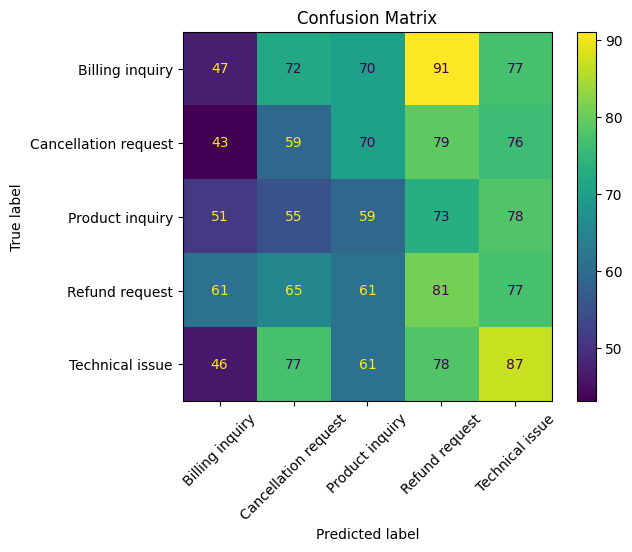

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions,
    xticks_rotation=45
)

plt.title("Confusion Matrix")
plt.show()

In [14]:
def predict_priority(text):

    text = text.lower()

    if any(word in text for word in
           ['urgent','critical','crash','payment failed']):
        return "High"

    elif any(word in text for word in
             ['issue','problem','slow']):
        return "Medium"

    else:
        return "Low"

In [15]:
sample_ticket = "payment failed and system crashed"

print("Priority:", predict_priority(sample_ticket))

Priority: High


In [16]:
import pickle

pickle.dump(model, open("category_model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

In [17]:
from google.colab import files

files.download("category_model.pkl")
files.download("vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>